# Statistical Model Comparison
Compares **Main Model** vs. three competitor models on a held-out test set.  
Each model is loaded, evaluated, then fully cleared from memory before the next one is loaded.

**Tests performed (Main vs. each competitor):**
- **McNemar's test** — correctness contingency (paired)
- **Wilcoxon signed-rank test** — per-sample confidence scores
- **DeLong's test** — AUC comparison (binary) or macro-OvR AUC
- **Bootstrap 95% CIs** — Accuracy, F1, AUC per model

## 0. Imports & Configuration

In [ ]:
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import random 

import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Layer, Conv2D, Dense,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Reshape, Multiply, Add, Activation, Concatenate
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
from sklearn.model_selection import train_test_split

from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings('ignore')

TF version: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ─── USER CONFIG ───────────────────────────────────────────────────────────────
MODEL_PATHS = {
    'MainModel'     : '../HAM10000 Dataset/Proposed CBAM-Xception-DermNet.keras',  
    'EfficientNetB0': 'EfficientNetB0.keras',         
    'VGG19'         : 'VGG19.keras', 
    'ResNet50'      : 'ResNet50.keras'     
}
MAIN_MODEL_KEY = 'MainModel'

N_BOOTSTRAP   = 1000   # bootstrap resamples for CIs
ALPHA         = 0.05   # significance level
RESULTS_DIR   = Path('stat_results')
RESULTS_DIR.mkdir(exist_ok=True)
\
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
img_shape=(*IMG_SIZE,3)
labels = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
csv_path = r'../HAM10000_metadata.csv'  
dataset_path = r'../HAM10000_organized' # Folder with class subfolders (organized)


print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

## 1. Data Setup


In [ ]:
# Read metadata
df_meta = pd.read_csv(csv_path)

# Helper to map image filename back to image_id
def get_image_id(filename):
    name = filename.split("/")[-1].split("\\")[-1] 
    # Remove augmentation suffix if exists
    if "_aug" in name:
        name = name.split("_aug")[0]
    return name.split(".")[0]

In [ ]:
# dataset_path: folder with organized classes
# df_meta: CSV with lesion_id, image_id, dx, etc.

# Build dataframe with image path, class, and lesion_id
image_paths = []
classes = []
lesion_ids = []

for label in os.listdir(dataset_path):
    class_dir = f"{dataset_path}/{label}"
    if not os.path.isdir(class_dir):
        continue
    for img_file in os.listdir(class_dir):
        img_path = f"{class_dir}/{img_file}"
        image_paths.append(img_path)
        classes.append(label)
        img_id = get_image_id(img_file)
        row = df_meta[df_meta['image_id'] == img_id]
        if row.empty:
            raise ValueError(f"{img_id} not found in metadata CSV")
        lesion_ids.append(row.iloc[0]['lesion_id'])

df = pd.DataFrame({
    'Image Path': image_paths,
    'Class': classes,
    'Lesion_ID': lesion_ids
})

# --- Stratified patient-level split ---
train_lesions = []
val_lesions = []
test_lesions = []

random.seed(42)

# Stratify lesions by class
for cls in df['Class'].unique():
    lesions_cls = df[df['Class'] == cls]['Lesion_ID'].unique()
    lesions_cls = list(lesions_cls)
    random.shuffle(lesions_cls)
    
    num_total = len(lesions_cls)
    num_test = max(1, int(num_total * 0.1))   # At least 1 lesion
    num_val = max(1, int(num_total * 0.2))    # ~20% for val
    num_train = num_total - num_test - num_val
    
    train_lesions.extend(lesions_cls[:num_train])
    val_lesions.extend(lesions_cls[num_train:num_train+num_val])
    test_lesions.extend(lesions_cls[num_train+num_val:])

# Convert to sets
train_lesions = set(train_lesions)
val_lesions = set(val_lesions)
test_lesions = set(test_lesions)

# Assign splits
train_dataframe = df[df['Lesion_ID'].isin(train_lesions)].reset_index(drop=True)
validation_dataframe = df[df['Lesion_ID'].isin(val_lesions)].reset_index(drop=True)
test_dataframe = df[df['Lesion_ID'].isin(test_lesions)].reset_index(drop=True)

# Check class balance
# print("Train class distribution:")
# print(train_dataframe['Class'].value_counts())
# print("\nValidation class distribution:")
# print(validation_dataframe['Class'].value_counts())
# print("\nTest class distribution:")
# print(test_dataframe['Class'].value_counts())

print(f"Train size: {len(train_dataframe)}, Val size: {len(validation_dataframe)}, Test size: {len(test_dataframe)}")


Train size: 32858, Validation size: 9388, Test size: 4695


In [5]:
def preprocess_image(image):
    # Convert image to uint8 if needed (required for CLAHE)
    if image.dtype != np.uint8:
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Convert to LAB color space
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # Apply CLAHE to the L-channel (lightness)
    clahe = cv2.createCLAHE(clipLimit=0.01, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])

    # Convert back to RGB
    image_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Apply Min-Max scaling to [0, 1]
    image_clahe = image_clahe.astype(np.float32)
    image_clahe = (image_clahe - np.min(image_clahe)) / (np.ptp(image_clahe) + 1e-8)  # np.ptp = max - min

    return image_clahe

In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)


train_data = train_datagen.flow_from_dataframe(train_dataframe, x_col='Image Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, seed=42)

validation_data = val_datagen.flow_from_dataframe(validation_dataframe, x_col='Image Path',
                                     y_col='Class', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE, seed=42)

test_data = test_datagen.flow_from_dataframe(test_dataframe, x_col='Image Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, shuffle=False, seed=42)

Found 32854 validated image filenames belonging to 7 classes.
Found 9387 validated image filenames belonging to 7 classes.
Found 4694 validated image filenames belonging to 7 classes.


In [7]:
# Ground-truth integer labels (derived from generator after fitting)
CLASS_NAMES  = list(test_data.class_indices.keys())   # e.g. ['Benign','Malignant']
N_CLASSES    = len(CLASS_NAMES)
TRUE_LABELS  = test_data.classes                       # integer array, length = N_samples
N_SAMPLES    = len(TRUE_LABELS)

print(f'Classes : {CLASS_NAMES}')
print(f'Samples : {N_SAMPLES}')

Classes : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Samples : 4694


## 2. Helper Functions

In [8]:
# serializable functions to load models

@tf.keras.utils.register_keras_serializable(package="Custom", name="F1Score")
class F1Score(tf.keras.metrics.Metric):
    """
    Custom Keras metric to compute the F1 Score.
    The F1 score is the harmonic mean of precision and recall.
    """

    def __init__(self, name='f1_score', **kwargs):
        """
        Initializes the F1Score metric. 
        - Uses Keras' Precision and Recall metrics as intermediate steps.
        """
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()  # Precision metric
        self.recall = tf.keras.metrics.Recall()  # Recall metric

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        Updates the state of the metric.
        - This method is called during training to update precision and recall.
        - The precision and recall states are updated based on true and predicted values.
        """
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        """
        Computes and returns the F1 score.
        - F1 score is calculated as the harmonic mean of precision and recall.
        - Prevents division by zero by adding a small epsilon value to the denominator.
        """
        p = self.precision.result()  # Get precision value
        r = self.recall.result()  # Get recall value
        return 2 * (p * r) / (p + r + tf.keras.backend.epsilon())  # Calculate F1 score

    def reset_states(self):
        """
        Resets the states of the precision and recall metrics.
        - This is called at the beginning of each epoch.
        """
        self.precision.reset_states()  # Reset precision state
        self.recall.reset_states()  # Reset recall state


# Channel Attention Block
@tf.keras.utils.register_keras_serializable(package="Custom", name="ChannelAttention")
class ChannelAttention(Layer):
    """
    Channel Attention Block (CA) that computes channel-wise attention.
    
    Args:
        reduction: The factor for reducing the number of channels in the intermediate layer.
    """
    def __init__(self, reduction=16, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        """
        Build the dense layers for the Channel Attention mechanism.
        - `shared_dense_one`: reduces channel dimensions.
        - `shared_dense_two`: restores the original channel dimensions.
        """
        channel = input_shape[-1]  # Number of channels in the input tensor
        self.shared_dense_one = Dense(channel // self.reduction, activation='relu', kernel_initializer='he_normal', use_bias=True)
        self.shared_dense_two = Dense(channel, kernel_initializer='he_normal', use_bias=True)

    def call(self, inputs):
        """
        Apply the Channel Attention mechanism:
        - Global Average Pooling (avg_pool) and Global Max Pooling (max_pool)
        - Process each through a set of shared dense layers.
        - Combine both attentions and apply a sigmoid function to get the attention weights.
        """
        # Global average and max pooling
        avg_pool = GlobalAveragePooling2D()(inputs)
        max_pool = GlobalMaxPooling2D()(inputs)

        # Apply shared dense layers for both average and max pooled features
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)

        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)

        # Combine both attention signals and apply sigmoid activation
        attention = Add()([avg_pool, max_pool])
        attention = Activation('sigmoid')(attention)

        # Reshape the attention to match the input dimensions and apply multiplication
        attention = Reshape((1, 1, -1))(attention)
        return Multiply()([inputs, attention])

# Spatial Attention Block
@tf.keras.utils.register_keras_serializable(package="Custom", name="SpatialAttention")
class SpatialAttention(Layer):
    """
    Spatial Attention Block (SA) that computes spatial attention across channels.
    """
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        # 2D convolution for spatial attention with a kernel size of 7x7 and sigmoid activation
        self.conv2d = Conv2D(filters=1, kernel_size=7, strides=1, padding='same', activation='sigmoid')

    def call(self, inputs):
        """
        Apply the Spatial Attention mechanism:
        - Apply both average and max pooling across the channel axis to extract spatial features.
        - Concatenate the two features and apply convolution to get spatial attention.
        """
        # Apply global average and max pooling along the channel axis
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)

        # Concatenate both pooled features
        concat = Concatenate(axis=-1)([avg_pool, max_pool])

        # Apply convolution to compute spatial attention map
        attention = self.conv2d(concat)

        # Multiply the attention map with the input to highlight important spatial features
        return Multiply()([inputs, attention])

# Full CBAM Block
def cbam_block(inputs, reduction=16):
    """
    CBAM (Convolutional Block Attention Module) that sequentially applies
    Channel Attention and Spatial Attention blocks.

    Args:
        inputs: Input tensor to the CBAM block.
        reduction: The factor for reducing the channel dimension in the Channel Attention block.
    
    Returns:
        The output tensor after applying both attention mechanisms.
    """
    # Apply Channel Attention followed by Spatial Attention
    x = ChannelAttention(reduction)(inputs)
    x = SpatialAttention()(x)
    return x

# Focal Loss
@tf.keras.utils.register_keras_serializable(package="Custom")
class FocalLoss(tf.keras.losses.Loss):

    def __init__(
        self,
        gamma=2.0,
        alpha=0.25,
        reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE,
        name="focal_loss",
    ):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)

        # Avoid numerical instability
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0)

        # Categorical cross entropy
        ce = -y_true * tf.math.log(y_pred)

        # Compute modulating factor
        p_t = y_true * y_pred
        modulating_factor = tf.pow(1.0 - p_t, self.gamma)

        # Apply alpha weighting
        alpha_factor = y_true * self.alpha

        loss = alpha_factor * modulating_factor * ce

        return tf.reduce_sum(loss, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "gamma": self.gamma,
            "alpha": self.alpha,
        })
        return config


In [ ]:
# ── Prediction helper ─────────────────────────────────────────────────────────
def predict_on_test(model, generator):
    """Run inference and return (probs, preds) without shuffling the generator."""
    generator.reset()
    probs = model.predict(generator, verbose=1, steps=len(generator))
    preds = np.argmax(probs, axis=1)
    return probs, preds


In [ ]:
# ── Memory cleanup ────────────────────────────────────────────────────────────
def clear_model(model):
    if model is not None:
        # Delete model and clear Keras backend session
        del model
        tf.keras.backend.clear_session()
    
    # Force garbage collection
    gc.collect()
    
    # Clear TF GPU cache (safe for Metal/Apple Silicon)
    if tf.config.list_physical_devices('GPU'):
        try:
            tf.keras.backend.clear_session()  # Extra clear
            # Limit growth instead of reset (avoids ValueError on Metal)
            gpus = tf.config.list_physical_devices('GPU')
            if gpus:
                tf.config.experimental.set_memory_growth(gpus[0], True)
        except Exception as e:
            print(f"  [⚠] GPU memory clear skipped: {e}")
    
    # Final GC
    gc.collect()
    print('  [✓] Model cleared & memory released')

In [ ]:
# ── Bootstrap CI ──────────────────────────────────────────────────────────────
def bootstrap_ci(y_true, y_pred, y_prob, n_classes,
                 n_boot=N_BOOTSTRAP, alpha=ALPHA, seed=42):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    rng   = np.random.default_rng(seed)
    accs, f1s, aucs = [], [], []
    avg   = 'binary' if n_classes == 2 else 'macro'

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), size=len(y_true), dtype=np.int64)
        yt  = y_true[idx]
        yp  = y_pred[idx]
        ypr = y_prob[idx]
        accs.append(accuracy_score(yt, yp))
        f1s.append(f1_score(yt, yp, average=avg, zero_division=0))
        try:
            if n_classes == 2:
                aucs.append(roc_auc_score(yt, ypr[:, 1]))
            else:
                aucs.append(roc_auc_score(yt, ypr, multi_class='ovr', average='macro'))
        except Exception:
            pass

    lo, hi = alpha / 2, 1 - alpha / 2
    return {
        'acc_mean': np.mean(accs),
        'acc_ci':   (np.quantile(accs, lo), np.quantile(accs, hi)),
        'f1_mean':  np.mean(f1s),
        'f1_ci':    (np.quantile(f1s, lo), np.quantile(f1s, hi)),
        'auc_mean': np.mean(aucs) if aucs else float('nan'),
        'auc_ci':   (np.quantile(aucs, lo), np.quantile(aucs, hi)) if aucs else (float('nan'), float('nan')),
    }

In [ ]:
# ── McNemar's test ────────────────────────────────────────────────────────────
def mcnemar_test(y_true, preds_a, preds_b):
    """
    Compares two classifiers on the same test set.
    Returns: statistic, p-value, contingency table.
    """
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)

    n00 = np.sum(~correct_a & ~correct_b)   # both wrong
    n01 = np.sum(~correct_a &  correct_b)   # a wrong, b correct
    n10 = np.sum( correct_a & ~correct_b)   # a correct, b wrong
    n11 = np.sum( correct_a &  correct_b)   # both correct

    table = np.array([[n11, n10], [n01, n00]])  # statsmodels convention
    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue, table

In [ ]:
# ── DeLong's AUC test (binary) ────────────────────────────────────────────────
# Reference: Sun & Xu (2014) – fast DeLong variance estimator
def _auc_variance_delong(y_true, pred_1, pred_2):
    """Internal: computes variance and covariance for two score vectors."""
    pos = y_true == 1; neg = y_true == 0
    m = pos.sum(); n = neg.sum()

    def _placement_values(scores_pos, scores_neg):
        V10 = np.array([np.mean(s > scores_neg) + 0.5 * np.mean(s == scores_neg)
                        for s in scores_pos])
        V01 = np.array([np.mean(s < scores_pos) + 0.5 * np.mean(s == scores_pos)
                        for s in scores_neg])
        return V10, V01

    V10_1, V01_1 = _placement_values(pred_1[pos], pred_1[neg])
    V10_2, V01_2 = _placement_values(pred_2[pos], pred_2[neg])

    S10 = np.cov(np.stack([V10_1, V10_2]))
    S01 = np.cov(np.stack([V01_1, V01_2]))

    var = S10 / m + S01 / n
    return var  # 2×2 covariance matrix of [AUC1, AUC2]

In [ ]:
def delong_test(y_true, prob_a, prob_b):
    """
    DeLong's test for two AUC values on the same test set (binary only).
    Returns: z-statistic, p-value.
    """
    from scipy.stats import norm

    if len(np.unique(y_true)) != 2:
        return float('nan'), float('nan')   # skip for multiclass

    auc_a = roc_auc_score(y_true, prob_a)
    auc_b = roc_auc_score(y_true, prob_b)

    try:
        var_matrix = _auc_variance_delong(y_true, prob_a, prob_b)
        # var of (AUC_a - AUC_b) = var_a + var_b - 2*cov_ab
        var_diff = var_matrix[0, 0] + var_matrix[1, 1] - 2 * var_matrix[0, 1]
        if var_diff <= 0:
            return float('nan'), float('nan')
        z = (auc_a - auc_b) / np.sqrt(var_diff)
        p = 2 * norm.sf(abs(z))
        return z, p
    except Exception as e:
        print(f'  DeLong error: {e}')
        return float('nan'), float('nan')


print('Helper functions loaded.')

Helper functions loaded.


## 3. Sequential Model Evaluation
Each model is loaded → predictions collected → memory fully cleared.

In [ ]:
all_results = {}   # { model_name: {'probs': ..., 'preds': ..., 'ci': ...} }

for name, path in MODEL_PATHS.items():
    print('\n' + '='*60)
    print(f'  Loading: {name}  |  {path}')
    print('='*60)

    # ── Load
    model = load_model(path, compile=False)
    print(f'  Parameters: {model.count_params():,}')

    # ── Predict
    probs, preds = predict_on_test(model, test_data)

    # ── Bootstrap metrics
    print('  Computing bootstrap CIs …')
    ci = bootstrap_ci(TRUE_LABELS, preds, probs, N_CLASSES)

    all_results[name] = {
        'probs': probs,
        'preds': preds,
        'ci':    ci,
        'n_params': model.count_params(),
    }

    print(f"  Acc  : {ci['acc_mean']:.4f}  95%CI [{ci['acc_ci'][0]:.4f}, {ci['acc_ci'][1]:.4f}]")
    print(f"  F1   : {ci['f1_mean']:.4f}  95%CI [{ci['f1_ci'][0]:.4f}, {ci['f1_ci'][1]:.4f}]")
    print(f"  AUC  : {ci['auc_mean']:.4f}  95%CI [{ci['auc_ci'][0]:.4f}, {ci['auc_ci'][1]:.4f}]")

    # ── Unload
    clear_model(model)

print('\n[✓] All models evaluated ')


  Loading: MainModel  |  ../HAM10000 Dataset/Proposed CBAM-Xception-DermNet.keras


2026-03-19 12:37:48.526254: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-19 12:37:48.526279: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-19 12:37:48.526284: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-19 12:37:48.526298: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-19 12:37:48.526306: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


  Parameters: 21,651,218


2026-03-19 12:37:49.672417: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 40s 269ms/step
  Computing bootstrap CIs …
  Acc  : 0.9936  95%CI [0.9913, 0.9957]
  F1   : 0.9936  95%CI [0.9912, 0.9957]
  AUC  : 0.9999  95%CI [0.9999, 1.0000]
  [⚠] GPU memory clear skipped: Physical devices cannot be modified after being initialized (common on Apple M4 Metal)
  [✓] Model cleared & memory released

  Loading: EfficientNetB0  |  EfficientNetB0.keras
  Parameters: 4,214,442
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step
  Computing bootstrap CIs …
  Acc  : 0.6875  95%CI [0.6740, 0.7009]
  F1   : 0.7017  95%CI [0.6888, 0.7146]
  AUC  : 0.9436  95%CI [0.9391, 0.9481]
  [⚠] GPU memory clear skipped: Physical devices cannot be modified after being initialized (common on Apple M4 Metal)
  [✓] Model cleared & memory released

  Loading: VGG19  |  VGG19.keras
  Parameters: 20,090,951
147/147 ━━━━━━━━━━━━━━━━━━━━ 71s 486ms/step
  Computing bootstrap CIs …
  Acc  : 0.9332  95%CI [0.9252, 0.9399]
  F1   : 0.9326  95%CI [0.9249, 0.9394]
  AUC  : 0.9958

## 4. Per-Model Classification Report

In [11]:
for name, res in all_results.items():
    print(f'\n── {name} ─────────────────────────────────')
    print(classification_report(
        TRUE_LABELS, res['preds'],
        target_names=CLASS_NAMES, digits=4
    ))


── MainModel ─────────────────────────────────
              precision    recall  f1-score   support

       akiec     0.9955    0.9985    0.9970       670
         bcc     0.9970    0.9955    0.9963       671
         bkl     0.9896    0.9955    0.9926       670
          df     0.9955    1.0000    0.9978       671
         mel     0.9939    0.9747    0.9842       671
          nv     0.9837    0.9910    0.9874       670
        vasc     1.0000    1.0000    1.0000       671

    accuracy                         0.9936      4694
   macro avg     0.9936    0.9936    0.9936      4694
weighted avg     0.9936    0.9936    0.9936      4694


── EfficientNetB0 ─────────────────────────────────
              precision    recall  f1-score   support

       akiec     0.8577    0.6030    0.7082       670
         bcc     0.7573    0.7303    0.7436       671
         bkl     0.6461    0.6104    0.6278       670
          df     0.9713    0.6051    0.7456       671
         mel     0.8345    0.51

## 5. Statistical Tests: Main Model vs. Each Competitor

In [14]:
main_preds = all_results[MAIN_MODEL_KEY]['preds']
main_probs = all_results[MAIN_MODEL_KEY]['probs']

competitors = [k for k in MODEL_PATHS if k != MAIN_MODEL_KEY]

stat_rows = []

for comp in competitors:
    comp_preds = all_results[comp]['preds']
    comp_probs = all_results[comp]['probs']

    print('\n' + '='*60)
    print(f'  {MAIN_MODEL_KEY}  vs.  {comp}')
    print('='*60)

    # ── McNemar's test ──────────────────────────────────────────
    mc_stat, mc_p, mc_table = mcnemar_test(TRUE_LABELS, main_preds, comp_preds)
    print(f'\n  McNemar\'s Test')
    print(f'    Contingency table (both✓ | main✓comp✗ | main✗comp✓ | both✗):')
    print(f'    [[{mc_table[0,0]:4d}  {mc_table[0,1]:4d}]')
    print(f'     [{mc_table[1,0]:4d}  {mc_table[1,1]:4d}]]')
    print(f'    χ² = {mc_stat:.4f},  p = {mc_p:.6f}',
          '  [SIGNIFICANT]' if mc_p < ALPHA else '  [not significant]')

    # ── Wilcoxon signed-rank test ───────────────────────────────
    # Use max-class confidence as a proxy for model certainty
    conf_main = np.max(main_probs, axis=1)
    conf_comp = np.max(comp_probs, axis=1)
    diff = conf_main - conf_comp

    if np.all(diff == 0):
        wil_stat, wil_p = float('nan'), float('nan')
    else:
        wil_stat, wil_p = wilcoxon(conf_main, conf_comp, alternative='two-sided')

    print(f'\n  Wilcoxon Signed-Rank Test (max-class confidence)')
    print(f'    W = {wil_stat:.4f},  p = {wil_p:.6f}',
          '  [SIGNIFICANT]' if wil_p < ALPHA else '  [not significant]')

    # ── DeLong's test (binary only; skipped gracefully for multiclass) ─
    if N_CLASSES == 2:
        delong_z, delong_p = delong_test(
            TRUE_LABELS, main_probs[:, 1], comp_probs[:, 1]
        )
        print(f'\n  DeLong\'s AUC Test')
        print(f'    z = {delong_z:.4f},  p = {delong_p:.6f}',
              '  [SIGNIFICANT]' if delong_p < ALPHA else '  [not significant]')
    else:
        delong_z, delong_p = float('nan'), float('nan')
        print('\n  DeLong\'s test: skipped (multiclass — use macro-AUC CIs instead)')

    stat_rows.append({
        'Comparison':        f'{MAIN_MODEL_KEY} vs {comp}',
        'McNemar_chi2':      round(mc_stat, 4),
        'McNemar_p':         round(mc_p, 6),
        'McNemar_sig':       mc_p < ALPHA,
        'Wilcoxon_W':        round(wil_stat, 4),
        'Wilcoxon_p':        round(wil_p, 6),
        'Wilcoxon_sig':      wil_p < ALPHA,
        'DeLong_z':          round(delong_z, 4),
        'DeLong_p':          round(delong_p, 6),
        'DeLong_sig':        delong_p < ALPHA,
    })

stat_df = pd.DataFrame(stat_rows)
print('\n\n── Summary Table ────────────────────────────────────')
display(stat_df)


  MainModel  vs.  EfficientNetB0

  McNemar's Test
    Contingency table (both✓ | main✓comp✗ | main✗comp✓ | both✗):
    [[3218  1446]
     [   8    22]]
    χ² = 1420.1988,  p = 0.000000   [SIGNIFICANT]

  Wilcoxon Signed-Rank Test (max-class confidence)
    W = 34029.0000,  p = 0.000000   [SIGNIFICANT]

  DeLong's test: skipped (multiclass — use macro-AUC CIs instead)

  MainModel  vs.  VGG19

  McNemar's Test
    Contingency table (both✓ | main✓comp✗ | main✗comp✓ | both✗):
    [[4363   301]
     [  17    13]]
    χ² = 251.8522,  p = 0.000000   [SIGNIFICANT]

  Wilcoxon Signed-Rank Test (max-class confidence)
    W = 386406.0000,  p = 0.000000   [SIGNIFICANT]

  DeLong's test: skipped (multiclass — use macro-AUC CIs instead)

  MainModel  vs.  ResNet50

  McNemar's Test
    Contingency table (both✓ | main✓comp✗ | main✗comp✓ | both✗):
    [[4613    51]
     [  21     9]]
    χ² = 11.6806,  p = 0.000632   [SIGNIFICANT]

  Wilcoxon Signed-Rank Test (max-class confidence)
    W = 187124.

,Comparison,McNemar_chi2,McNemar_p,McNemar_sig,Wilcoxon_W,Wilcoxon_p,Wilcoxon_sig,DeLong_z,DeLong_p,DeLong_sig
0,MainModel vs EfficientNetB0,1420.1988,0.000000,True,34029.0,0.0,True,NaN,NaN,False
1,MainModel vs VGG19,251.8522,0.000000,True,386406.0,0.0,True,NaN,NaN,False
2,MainModel vs ResNet50,11.6806,0.000632,True,187124.0,0.0,True,NaN,NaN,False


## 6. Bootstrap CI Summary Table

In [15]:
ci_rows = []
for name, res in all_results.items():
    ci = res['ci']
    ci_rows.append({
        'Model':           name,
        'Accuracy':        f"{ci['acc_mean']:.4f}",
        'Acc 95% CI':      f"[{ci['acc_ci'][0]:.4f}, {ci['acc_ci'][1]:.4f}]",
        'F1 (macro)':      f"{ci['f1_mean']:.4f}",
        'F1 95% CI':       f"[{ci['f1_ci'][0]:.4f}, {ci['f1_ci'][1]:.4f}]",
        'AUC':             f"{ci['auc_mean']:.4f}",
        'AUC 95% CI':      f"[{ci['auc_ci'][0]:.4f}, {ci['auc_ci'][1]:.4f}]",
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)

,Model,Accuracy,Acc 95% CI,F1 (macro),F1 95% CI,AUC,AUC 95% CI
0,MainModel,0.9936,"[0.9913, 0.9957]",0.9936,"[0.9912, 0.9957]",0.9999,"[0.9999, 1.0000]"
1,EfficientNetB0,0.6875,"[0.6740, 0.7009]",0.7017,"[0.6888, 0.7146]",0.9436,"[0.9391, 0.9481]"
2,VGG19,0.9332,"[0.9252, 0.9399]",0.9326,"[0.9249, 0.9394]",0.9958,"[0.9950, 0.9964]"
3,ResNet50,0.9873,"[0.9842, 0.9904]",0.9873,"[0.9843, 0.9903]",0.9996,"[0.9993, 0.9998]"


## 7. Visualisations

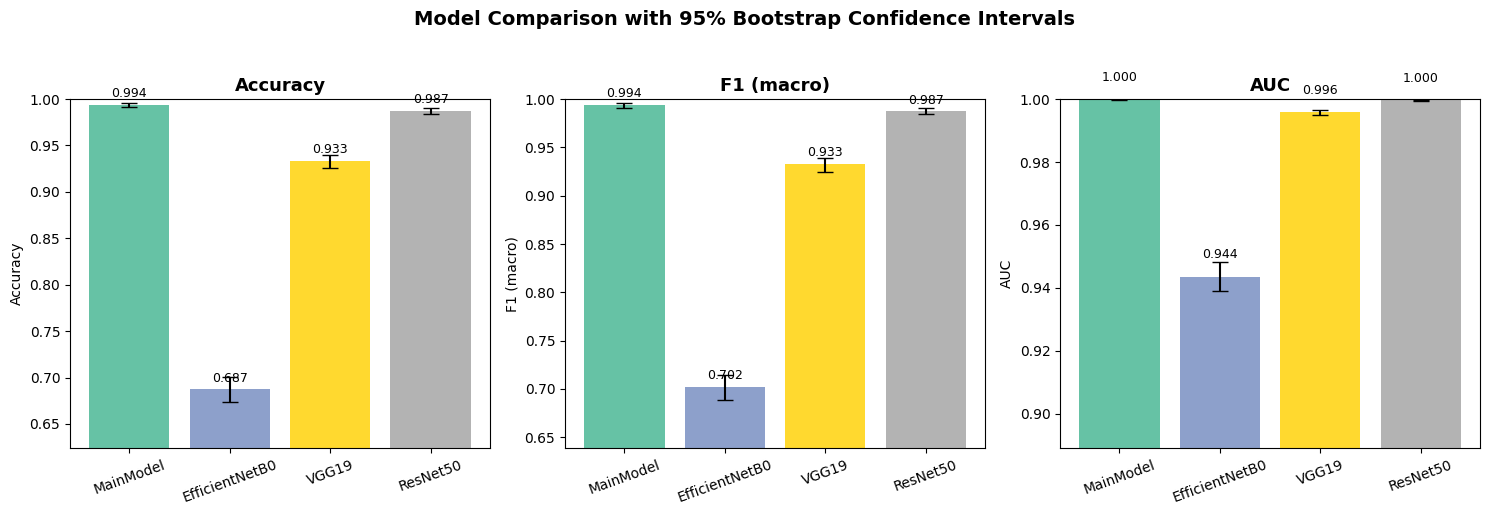

In [16]:
# ── 7a. Metric comparison bar chart with CI error bars ────────────────────────
metrics = ['acc', 'f1', 'auc']
labels  = ['Accuracy', 'F1 (macro)', 'AUC']
model_names = list(all_results.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

for ax, metric, label in zip(axes, metrics, labels):
    means  = [all_results[m]['ci'][f'{metric}_mean'] for m in model_names]
    ci_lo  = [all_results[m]['ci'][f'{metric}_ci'][0] for m in model_names]
    ci_hi  = [all_results[m]['ci'][f'{metric}_ci'][1] for m in model_names]
    yerr   = [np.array(means) - np.array(ci_lo),
               np.array(ci_hi) - np.array(means)]

    bars = ax.bar(model_names, means, color=colors, yerr=yerr,
                  capsize=6, error_kw={'linewidth': 1.5})
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(max(0, min(ci_lo) - 0.05), min(1, max(ci_hi) + 0.05))
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=20)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison with 95% Bootstrap Confidence Intervals',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

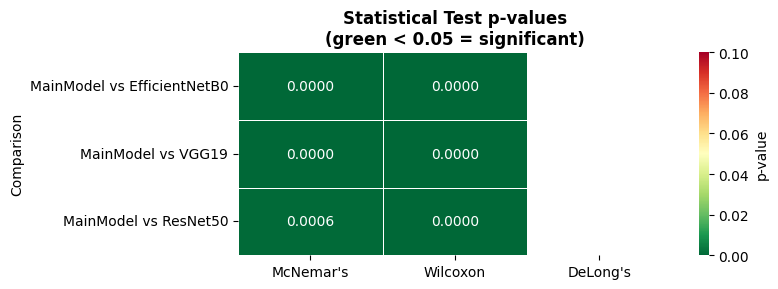

In [17]:
# ── 7b. p-value heatmap ───────────────────────────────────────────────────────
if not stat_df.empty:
    pval_data = stat_df[['Comparison', 'McNemar_p', 'Wilcoxon_p', 'DeLong_p']].copy()
    pval_data = pval_data.set_index('Comparison')
    pval_data.columns = ["McNemar's", 'Wilcoxon', "DeLong's"]

    fig, ax = plt.subplots(figsize=(8, max(3, len(competitors))))
    sns.heatmap(
        pval_data.astype(float), annot=True, fmt='.4f',
        cmap='RdYlGn_r', vmin=0, vmax=0.1, linewidths=0.5,
        ax=ax, cbar_kws={'label': 'p-value'}
    )
    ax.set_title('Statistical Test p-values\n(green < 0.05 = significant)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'pvalue_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

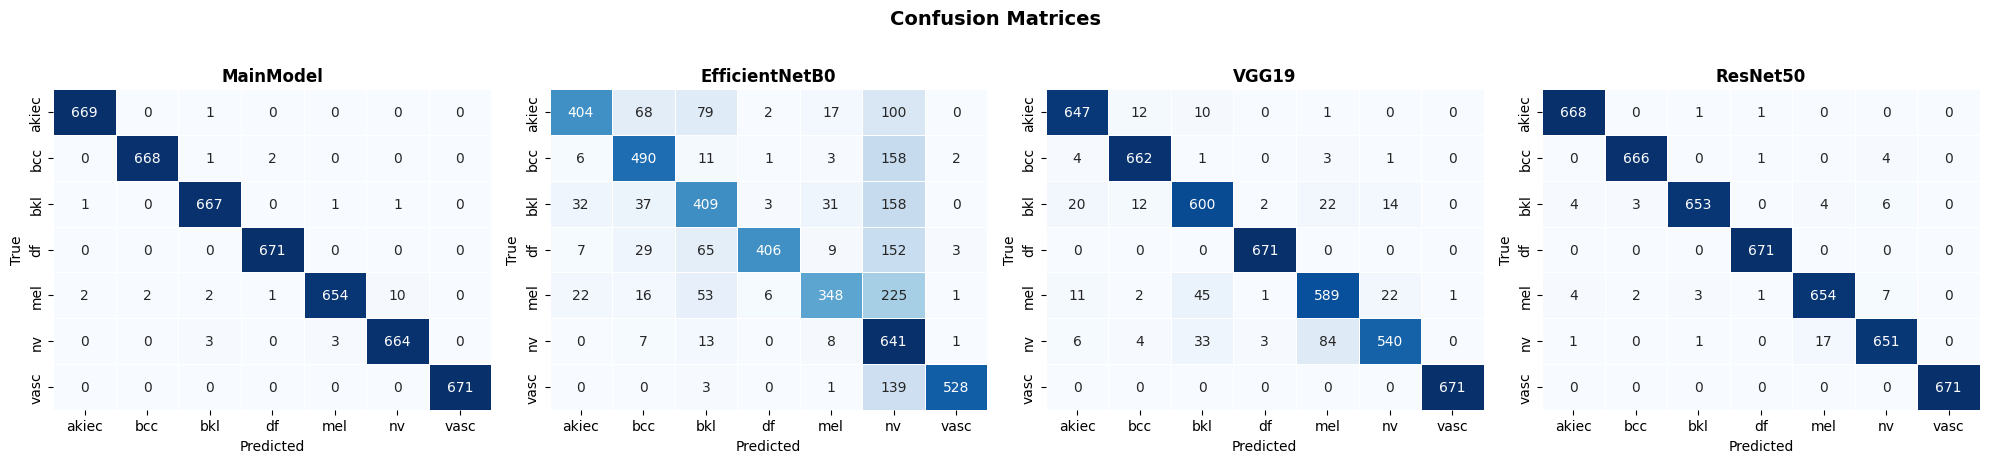

In [18]:
# ── 7c. Confusion matrices ────────────────────────────────────────────────────
n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, all_results.items()):
    cm = confusion_matrix(TRUE_LABELS, res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export Results to CSV

In [19]:
stat_df.to_csv(RESULTS_DIR / 'statistical_tests.csv', index=False)
ci_df.to_csv(RESULTS_DIR  / 'bootstrap_ci.csv', index=False)
print(f'Results saved to: {RESULTS_DIR.resolve()}')
print('  • statistical_tests.csv')
print('  • bootstrap_ci.csv')
print('  • metric_comparison.png')
print('  • pvalue_heatmap.png')
print('  • confusion_matrices.png')

Results saved to: /Users/faysalahmmed/Desktop/Files/ALL-Projects-U.G-/Skin Cancer Classification with Xception+40 Model Evaluation/stastical comparison/stat_results
  • statistical_tests.csv
  • bootstrap_ci.csv
  • metric_comparison.png
  • pvalue_heatmap.png
  • confusion_matrices.png
